# Hydraulic Class Comparison (Storage vs No-Storage)

This notebook compares hydraulic classes with the same photosynthesis module (`C3_cs_reduc`):

- `HalophyteStemStorageMultiComp`
- `HalophyteStemLeafStorageMultiComp`
- `HalophyteNoStorageMultiComp`

The setup uses updated initialization variable names (`vwi_stem`, `c_stem`) and includes a stem+leaf storage run using class defaults for leaf-storage parameters.

In [ ]:
%load_ext autoreload
%autoreload 2
%aimport hydraulics
%aimport species_traits

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from species_traits import *
from soil import SoilMultiple, Loam, DrydownSoil
from defs import SimulationMultiComp, Atmosphere, steps
from photosynthesis import C3_cs_reduc
import hydraulics

print("Libraries imported successfully")

Libraries imported successfully


## Configuration

In [22]:
# Simulation configuration
duration = 14
timestepM = 30
dt = timestepM * 60.0
weatherFile = r"sample_data\AgadirInterp30.xlsx"

# Multi-compartment soil configuration
num_compartments = 2
zr_arr = np.array([1.0, 1.0])
s_init_arr = np.array([0.4, 0.4])
cs_init_arr = np.array([35.0, 35.0])
root_frac_arr = np.array([0.5, 0.5])
B_param = 500

# Stem storage PV parameters
wr_stem = 0.1
wft_stem = 1.0
pi0_stem = -1.1
eta_stem = 5
mcap_stem = 12

# Leaf storage PV parameters
wr_leaf = 0.1
wft_leaf = 1.0
pi0_leaf = -1.4
eta_leaf = 5
mcap_leaf = 12

# Updated initialization names (future-proof for extra hydraulic classes)
# Use sub-saturated initial storage to reveal storage/no-storage divergence in ev.
vwi_stem = 0.75
c_stem = None

# Stem storage potential mode. In 'bartlett' mode, c_stem does not directly control psi_wf.
# Switch to 'legacy' if you want c_stem to directly influence storage water potential.
psi_wf_mode_stem = "bartlett"

# Test varying values of GWMAX to explore sensitivity of storage dynamics
gwmax_override_stem = 0.04  # Set to None to use species default GWMAX.

# Optional placeholders for a future leaf+stem storage hydraulic class
vwi_leaf = None
c_leaf = None

# Fallback for stem-storage runs when c_stem is intentionally left None
c_stem_default = 5.0

print(f"Duration: {duration} days | Timestep: {timestepM} minutes")
print(f"Compartments: {num_compartments}, root fractions: {root_frac_arr}")
print(f"Init vars -> vwi_stem: {vwi_stem}, c_stem: {c_stem}, vwi_leaf: {vwi_leaf}, c_leaf: {c_leaf}")
print(f"Stem psi_wf_mode: {psi_wf_mode_stem}")
print(f"Stem GWMAX override: {gwmax_override_stem}")

Duration: 14 days | Timestep: 30 minutes
Compartments: 2, root fractions: [0.5 0.5]
Init vars -> vwi_stem: 0.75, c_stem: None, vwi_leaf: None, c_leaf: None
Stem psi_wf_mode: bartlett
Stem GWMAX override: 0.04


In [23]:
# Load weather data
df = pd.read_excel(weatherFile, engine="openpyxl")

tempC = df["Temperature"]
taInp = list((tempC + 273.0).values)

rh = df["Relative Humidity"]
A_SAT = 611.2
B_SAT = 17.67
C_SAT = 243.5
P_ATM = 101325
psat = A_SAT * np.exp((B_SAT * tempC) / (C_SAT + tempC))
qaInp = list((0.622 * rh / 100.0 * psat / P_ATM).values)

phiInp = list(df["GHI"].values)

print(f"Weather loaded: {len(taInp)} timesteps")

Weather loaded: 17521 timesteps


## Initialize Models

In [24]:
# Compare hydraulic classes while keeping photosynthesis fixed
hydraulic_builders = {
    "StemStorage": lambda species_obj, atmosphere_obj, soil_obj, photo_obj: hydraulics.HalophyteStemStorageMultiComp(
        species=species_obj,
        atm=atmosphere_obj,
        soil=soil_obj,
        photo=photo_obj,
        vwi_stem=vwi_stem,
        c_stem=(c_stem if c_stem is not None else c_stem_default),
        s_arr=s_init_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        cs_arr=cs_init_arr,
        wr_stem=wr_stem,
        wft_stem=wft_stem,
        pi0_stem=pi0_stem,
        eta_stem=eta_stem,
        mcap_stem=mcap_stem,
        dt=dt,
        psi_wf_mode=psi_wf_mode_stem,
    ),
    "StemLeafStorage": lambda species_obj, atmosphere_obj, soil_obj, photo_obj: hydraulics.HalophyteStemLeafStorageMultiComp(
        species=species_obj,
        atm=atmosphere_obj,
        soil=soil_obj,
        photo=photo_obj,
        vwi_stem=vwi_stem,
        c_stem=(c_stem if c_stem is not None else c_stem_default),
        s_arr=s_init_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        cs_arr=cs_init_arr,
        wr_stem=wr_stem,
        wft_stem=wft_stem,
        pi0_stem=pi0_stem,
        eta_stem=eta_stem,
        mcap_stem=mcap_stem,
        wr_leaf=wr_leaf,
        wft_leaf=wft_leaf,
        pi0_leaf=pi0_leaf,
        eta_leaf=eta_leaf,
        mcap_leaf=mcap_leaf,
        dt=dt,
        psi_wf_mode=psi_wf_mode_stem,
    ),
    "NoStorage": lambda species_obj, atmosphere_obj, soil_obj, photo_obj: hydraulics.HalophyteNoStorageMultiComp(
        species=species_obj,
        atm=atmosphere_obj,
        soil=soil_obj,
        photo=photo_obj,
        vwi_stem=vwi_stem,
        c_stem=c_stem,
        s_arr=s_init_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        cs_arr=cs_init_arr,
        wr_stem=wr_stem,
        wft_stem=wft_stem,
        pi0_stem=pi0_stem,
        eta_stem=eta_stem,
        mcap_stem=mcap_stem,
        dt=dt,
        psi_wf_mode=psi_wf_mode_stem,
    ),
}

def initialize_simulation(hydraulic_name):
    species_obj = Pecan()
    atmosphere_obj = Atmosphere(phiInp[0], taInp[0], qaInp[0])
    soil_obj = SoilMultiple(
        stype=Loam(),
        dynamics=DrydownSoil(),
        zr=zr_arr,
        s=s_init_arr,
        cs=cs_init_arr,
    )

    # Optional storage-only coupling override for diagnostics/comparison clarity.
    if hydraulic_name in ["StemStorage", "StemLeafStorage"] and gwmax_override_stem is not None:
        species_obj.GWMAX = gwmax_override_stem

    # Fixed photosynthesis model for both hydraulic configurations
    photo_obj = C3_cs_reduc(species_obj, atmosphere_obj, cs_init_arr)

    hydro_obj = hydraulic_builders[hydraulic_name](species_obj, atmosphere_obj, soil_obj, photo_obj)

    plant_obj = SimulationMultiComp(
        species_cls=species_obj,
        atm_cls=atmosphere_obj,
        soil_cls=soil_obj,
        photo_cls=photo_obj,
        hydro_cls=hydro_obj,
        zr_arr=zr_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        dt=dt,
    )

    return plant_obj, hydro_obj

model_runs = {}
for hydraulic_name in hydraulic_builders:
    plant_obj, hydro_obj = initialize_simulation(hydraulic_name)
    model_runs[hydraulic_name] = {"plant": plant_obj, "hydro": hydro_obj}
    print(f"{hydraulic_name} initialized")
    if hasattr(hydro_obj, "w"):
        print(f"  Initial relative storage water content w: {hydro_obj.w:.3f}")
    if hasattr(hydro_obj, "w_stem"):
        print(f"  Initial stem relative water content w_stem: {hydro_obj.w_stem:.3f}")
    if hasattr(hydro_obj, "w_leaf"):
        print(f"  Initial leaf relative water content w_leaf: {hydro_obj.w_leaf:.3f}")
    if hasattr(hydro_obj, "c_stem"):
        print(f"  Initial stem concentration c_stem: {hydro_obj.c_stem}")
    if hasattr(hydro_obj, "c_leaf"):
        print(f"  Initial leaf concentration c_leaf: {hydro_obj.c_leaf}")
    if hasattr(hydro_obj, "GWMAX"):
        print(f"  GWMAX used: {hydro_obj.GWMAX}")
    print(f"  Initial leaf water potential psi_l: {hydro_obj.psi_l:.3f} MPa")

print("\nHydraulic comparison setup complete.")

StemStorage initialized
  Initial relative storage water content w: 0.750
  Initial stem concentration c_stem: 5.0
  GWMAX used: 0.04
  Initial leaf water potential psi_l: -1.212 MPa
StemLeafStorage initialized
  Initial stem relative water content w_stem: 0.750
  Initial leaf relative water content w_leaf: 1.000
  Initial stem concentration c_stem: 5.0
  Initial leaf concentration c_leaf: 5.0
  Initial leaf water potential psi_l: -1.180 MPa
NoStorage initialized
  Initial leaf water potential psi_l: -0.549 MPa

Hydraulic comparison setup complete.


In [25]:
# Select hydraulic variants to run
selected_hydraulic_models = ["StemStorage", "StemLeafStorage", "NoStorage"]
print(f"Selected hydraulic variants: {selected_hydraulic_models}")

Selected hydraulic variants: ['StemStorage', 'StemLeafStorage', 'NoStorage']


In [26]:
print(f"Running simulation for {duration} days...")
n_steps = steps(duration, int(timestepM))
progress_stride = max(1, n_steps // 4)

results_by_hydraulic = {}
for model_name in selected_hydraulic_models:
    if model_name not in model_runs:
        raise ValueError(f"Hydraulic model '{model_name}' is not initialized. Available: {list(model_runs.keys())}")

    plant_model = model_runs[model_name]["plant"]
    print(f"\nStarting {model_name}...")

    for i in range(n_steps):
        plant_model.update(dt, phiInp[i], taInp[i], qaInp[i])
        if (i + 1) % progress_stride == 0 or i == 0 or i == n_steps - 1:
            print(f"  {model_name}: {i + 1}/{n_steps} timesteps ({(i + 1) / n_steps * 100:.1f}%)")

    results_by_hydraulic[model_name] = plant_model.output()
    print(f"Completed {model_name}")

print("\nAll hydraulic simulations complete.")
print(f"Available hydraulic models: {list(results_by_hydraulic.keys())}")

Running simulation for 14 days...

Starting StemStorage...
  StemStorage: 1/672 timesteps (0.1%)
  StemStorage: 168/672 timesteps (25.0%)
  StemStorage: 336/672 timesteps (50.0%)
  StemStorage: 504/672 timesteps (75.0%)
  StemStorage: 672/672 timesteps (100.0%)
Completed StemStorage

Starting StemLeafStorage...
  StemLeafStorage: 1/672 timesteps (0.1%)
  StemLeafStorage: 168/672 timesteps (25.0%)
  StemLeafStorage: 336/672 timesteps (50.0%)
  StemLeafStorage: 504/672 timesteps (75.0%)
  StemLeafStorage: 672/672 timesteps (100.0%)
Completed StemLeafStorage

Starting NoStorage...
  NoStorage: 1/672 timesteps (0.1%)
  NoStorage: 168/672 timesteps (25.0%)
  NoStorage: 336/672 timesteps (50.0%)
  NoStorage: 504/672 timesteps (75.0%)
  NoStorage: 672/672 timesteps (100.0%)
Completed NoStorage

All hydraulic simulations complete.
Available hydraulic models: ['StemStorage', 'StemLeafStorage', 'NoStorage']


## Water Balance Diagnostics by Model

Check node balance closure for each model run at node B (root interface), node X (xylem junction) and node L (leaf storage junction).

In [27]:
for model_name, results in results_by_hydraulic.items():
    qs_arr = np.array(results["qs"])

    qbx_arr = np.array(results["qbx"])

    ev_arr = np.array(results["ev"])



    # Stem-storage flux is available for storage models; default to zeros for NoStorage.
    if "qw_stem" in results:
        qw_stem_arr = np.array(results["qw_stem"])

    else:
        qw_stem_arr = np.zeros_like(ev_arr, dtype=float)



    # Leaf-node flux terms are only available for the stem+leaf storage model.
    has_leaf_storage = ("qxl" in results) and ("qw_leaf" in results)

    if has_leaf_storage:
        qxl_arr = np.array(results["qxl"])

        qw_leaf_arr = np.array(results["qw_leaf"])



    if qs_arr.ndim == 1:
        qs_total = qs_arr

    else:
        qs_total = np.sum(qs_arr, axis=0)



    n_lengths = [len(qbx_arr), len(qs_total), len(ev_arr), len(qw_stem_arr)]

    if has_leaf_storage:
        n_lengths.extend([len(qxl_arr), len(qw_leaf_arr)])

    n_bal = min(n_lengths)



    qbx_bal = qbx_arr[:n_bal]

    qs_bal = qs_total[:n_bal]

    ev_bal = ev_arr[:n_bal]

    qw_stem_bal = qw_stem_arr[:n_bal]



    node_b_balance = qbx_bal - qs_bal



    if has_leaf_storage:
        qxl_bal = qxl_arr[:n_bal]

        qw_leaf_bal = qw_leaf_arr[:n_bal]

        node_x_balance = qbx_bal + qw_stem_bal - qxl_bal

        node_l_balance = qxl_bal + qw_leaf_bal - ev_bal

    else:
        node_x_balance = qbx_bal + qw_stem_bal - ev_bal



    mean_flux = np.mean(np.abs(ev_bal))

    if mean_flux > 0:
        rel_error_b = np.abs(node_b_balance.mean()) / mean_flux * 100.0

        rel_error_x = np.abs(node_x_balance.mean()) / mean_flux * 100.0

        if has_leaf_storage:
            rel_error_l = np.abs(node_l_balance.mean()) / mean_flux * 100.0

    else:
        rel_error_b = np.nan

        rel_error_x = np.nan

        if has_leaf_storage:
            rel_error_l = np.nan



    print(f"\n{model_name} Water Balance Diagnostics:")

    print(f"  Node B (root interface) mean balance: {node_b_balance.mean():.6e} um/s")

    print(f"  Node B max absolute error: {np.abs(node_b_balance).max():.6e} um/s")

    print(f"  Node B relative error: {rel_error_b:.3f}% of mean transpiration flux")



    print(f"  Node X (xylem junction) mean balance: {node_x_balance.mean():.6e} um/s")

    print(f"  Node X max absolute error: {np.abs(node_x_balance).max():.6e} um/s")

    print(f"  Node X relative error: {rel_error_x:.3f}% of mean transpiration flux")



    if has_leaf_storage:
        print(f"  Node L (leaf junction) mean balance: {node_l_balance.mean():.6e} um/s")

        print(f"  Node L max absolute error: {np.abs(node_l_balance).max():.6e} um/s")

        print(f"  Node L relative error: {rel_error_l:.3f}% of mean transpiration flux")



StemStorage Water Balance Diagnostics:
  Node B (root interface) mean balance: -3.020277e-19 um/s
  Node B max absolute error: 4.423545e-17 um/s
  Node B relative error: 0.000% of mean transpiration flux
  Node X (xylem junction) mean balance: -3.383429e-06 um/s
  Node X max absolute error: 2.134270e-04 um/s
  Node X relative error: 0.065% of mean transpiration flux

StemLeafStorage Water Balance Diagnostics:
  Node B (root interface) mean balance: 2.755681e-19 um/s
  Node B max absolute error: 5.290907e-17 um/s
  Node B relative error: 0.000% of mean transpiration flux
  Node X (xylem junction) mean balance: -1.337700e-05 um/s
  Node X max absolute error: 5.988704e-04 um/s
  Node X relative error: 0.258% of mean transpiration flux
  Node L (leaf junction) mean balance: 9.943065e-06 um/s
  Node L max absolute error: 5.032066e-04 um/s
  Node L relative error: 0.192% of mean transpiration flux

NoStorage Water Balance Diagnostics:
  Node B (root interface) mean balance: -1.271356e-19 um

## Comparison Plots

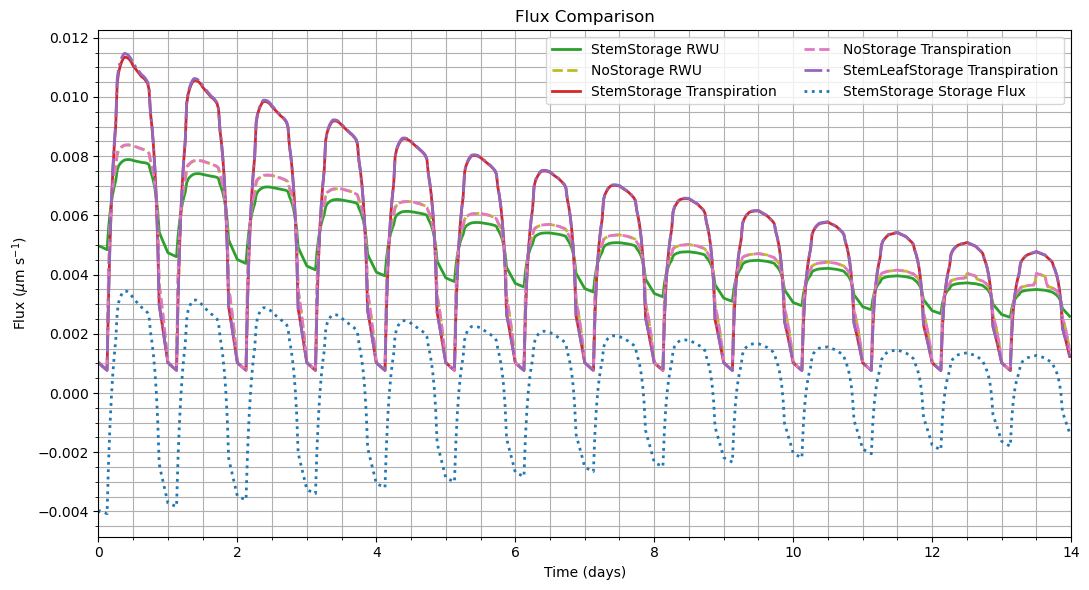

Time axis spans 0.000 to 13.979 days with 672 steps.
Integrated summed qs (StemStorage): 3.205 um
Integrated summed qs (NoStorage): 2.916 um
Integrated transpiration (StemStorage): 3.477 um
Integrated transpiration (NoStorage): 2.917 um
Integrated transpiration (StemLeafStorage): 3.485 um
Integrated storage flux (StemStorage): 0.270 um


In [28]:
# Compare summed soil flux, storage flux, and transpiration flux
model_a = "StemStorage"
model_b = "NoStorage"
model_c = "StemLeafStorage"

qs_a_raw = np.array(results_by_hydraulic[model_a]["qs"])
qs_b_raw = np.array(results_by_hydraulic[model_b]["qs"])

ev_a = np.array(results_by_hydraulic[model_a]["ev"])
ev_b = np.array(results_by_hydraulic[model_b]["ev"])
ev_c = np.array(results_by_hydraulic[model_c]["ev"])

q_storage_a = np.array(results_by_hydraulic[model_a]["qw"])



# qs is stored by compartment, so sum across compartments at each timestep.
qs_a_sum = np.sum(qs_a_raw, axis=0)

qs_b_sum = np.sum(qs_b_raw, axis=0)



n_plot = min(len(qs_a_sum), len(qs_b_sum), len(ev_a), len(ev_b), len(ev_c), len(q_storage_a))
expected_steps = int(duration * 24 * 60 / timestepM)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")


time_plot = np.linspace(0.0, duration, num=n_plot, endpoint=False)



qs_a_plot = qs_a_sum[:n_plot]
qs_b_plot = qs_b_sum[:n_plot]
ev_a_plot = ev_a[:n_plot]
ev_b_plot = ev_b[:n_plot]
ev_c_plot = ev_c[:n_plot]
q_storage_plot = q_storage_a[:n_plot]


plt.figure(figsize=(11, 6))
plt.title("Flux Comparison")
plt.xlabel("Time (days)")
plt.ylabel(r"Flux ($\mu$m s$^{-1}$)")
plt.plot(time_plot, qs_a_plot, linewidth=2, color="tab:green", label=f"{model_a} RWU")
plt.plot(time_plot, qs_b_plot, linewidth=2, color="tab:olive", linestyle="--", label=f"{model_b} RWU")
plt.plot(time_plot, ev_a_plot, linewidth=2, color="tab:red", label=f"{model_a} Transpiration")
plt.plot(time_plot, ev_b_plot, linewidth=2, color="tab:pink", linestyle="--", label=f"{model_b} Transpiration")
plt.plot(time_plot, ev_c_plot, linewidth=2, color="tab:purple", linestyle="-.", label=f"{model_c} Transpiration")
plt.plot(time_plot, q_storage_plot, linewidth=2, color="tab:blue", linestyle=":", label=f"{model_a} Storage Flux")
plt.xlim(0, duration)
plt.minorticks_on()
plt.grid(visible=True, which="both", axis="both")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


print(f"Time axis spans {time_plot[0]:.3f} to {time_plot[-1]:.3f} days with {n_plot} steps.")
print(f"Integrated summed qs ({model_a}): {qs_a_plot.sum():.3f} um")
print(f"Integrated summed qs ({model_b}): {qs_b_plot.sum():.3f} um")
print(f"Integrated transpiration ({model_a}): {ev_a_plot.sum():.3f} um")
print(f"Integrated transpiration ({model_b}): {ev_b_plot.sum():.3f} um")
print(f"Integrated transpiration ({model_c}): {ev_c_plot.sum():.3f} um")
print(f"Integrated storage flux ({model_a}): {q_storage_plot.sum():.3f} um")

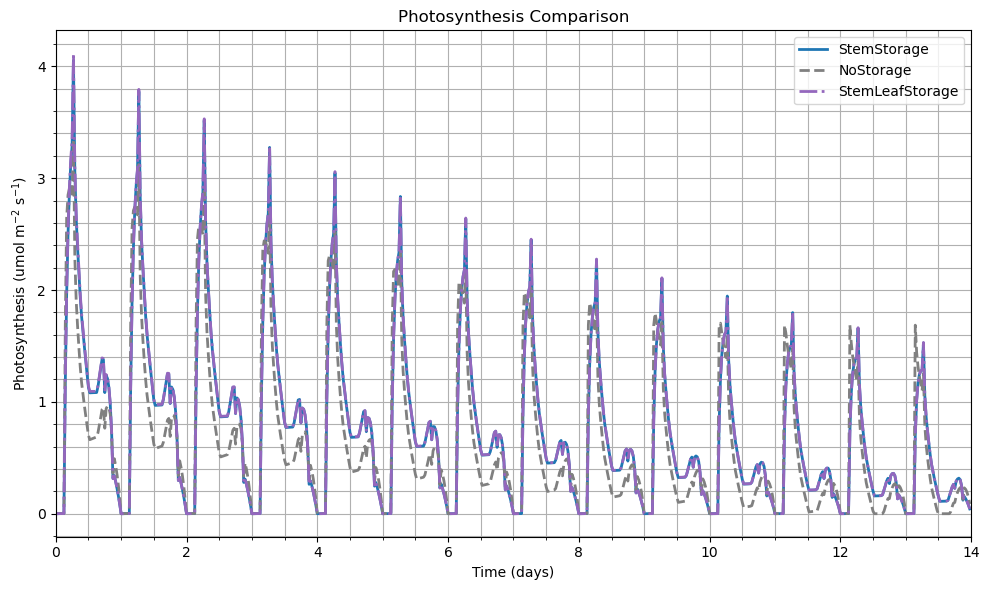

Time axis spans 0.000 to 13.979 days with 672 steps.
Integrated photosynthesis (StemStorage): 510.058 um
Integrated photosynthesis (NoStorage): 416.126 um
Integrated photosynthesis (StemLeafStorage): 511.971 um


In [29]:
# Photosynthesis comparison
model_a = "StemStorage"
model_b = "NoStorage"
model_c = "StemLeafStorage"

An_a = np.array(results_by_hydraulic[model_a]["a"])

An_b = np.array(results_by_hydraulic[model_b]["a"])

An_c = np.array(results_by_hydraulic[model_c]["a"])



n_plot = min(len(An_a), len(An_b), len(An_c))
expected_steps = int(duration * 24 * 60 / timestepM)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")


time_plot = np.linspace(0.0, duration, num=n_plot, endpoint=False)



plt.figure(figsize=(10, 6))
plt.title("Photosynthesis Comparison")
plt.xlabel("Time (days)")
plt.ylabel("Photosynthesis (umol m$^{-2}$ s$^{-1}$)")
plt.plot(time_plot, An_a[:n_plot], linewidth=2, color="tab:blue", label=model_a)
plt.plot(time_plot, An_b[:n_plot], linewidth=2, linestyle="--", color="gray", label=model_b)
plt.plot(time_plot, An_c[:n_plot], linewidth=2, linestyle="-.", color="tab:purple", label=model_c)
plt.xlim(0, duration)
plt.minorticks_on()
plt.grid(visible=True, which="both", axis="both")
plt.legend()
plt.tight_layout()
plt.show()


print(f"Time axis spans {time_plot[0]:.3f} to {time_plot[-1]:.3f} days with {n_plot} steps.")
print(f"Integrated photosynthesis ({model_a}): {An_a[:n_plot].sum():.3f} um")
print(f"Integrated photosynthesis ({model_b}): {An_b[:n_plot].sum():.3f} um")
print(f"Integrated photosynthesis ({model_c}): {An_c[:n_plot].sum():.3f} um")

In [30]:
Pecan.GCUT
Pecan.GWMAX

0.025595238095238098

[-0.37027693 -0.37040067 -0.37052436 -0.37064798 -0.37077155 -0.37089507
 -0.37101853 -0.37114583 -0.371276   -0.37140836 -0.37154245 -0.3716779
 -0.37181448 -0.3719531  -0.37209256 -0.3722325  -0.37237281 -0.37251344
 -0.37265432 -0.37279536 -0.37293652 -0.37307779 -0.37321912 -0.37336048
 -0.37350184 -0.37364323 -0.37378466 -0.37392612 -0.37406762 -0.37420914
 -0.3743507  -0.37449234 -0.37463402 -0.37477573 -0.37491745 -0.375059
 -0.37519948 -0.37533923 -0.37547806 -0.37561564 -0.37575148 -0.37588481
 -0.37601439 -0.37614332 -0.37627168 -0.37639948 -0.37652671 -0.37665336
 -0.37677946 -0.37690549 -0.37703146 -0.37715737 -0.37728322 -0.37740901
 -0.37753476 -0.37766431 -0.37779666 -0.37793112 -0.37806722 -0.37820462
 -0.37834307 -0.37848343 -0.37862457 -0.37876615 -0.37890808 -0.37905031
 -0.37919277 -0.37933539 -0.37947814 -0.37962098 -0.37976389 -0.37990684
 -0.3800498  -0.3801928  -0.38033583 -0.38047889 -0.38062198 -0.38076511
 -0.38090827 -0.38105148 -0.38119474 -0.38133802 -0.38

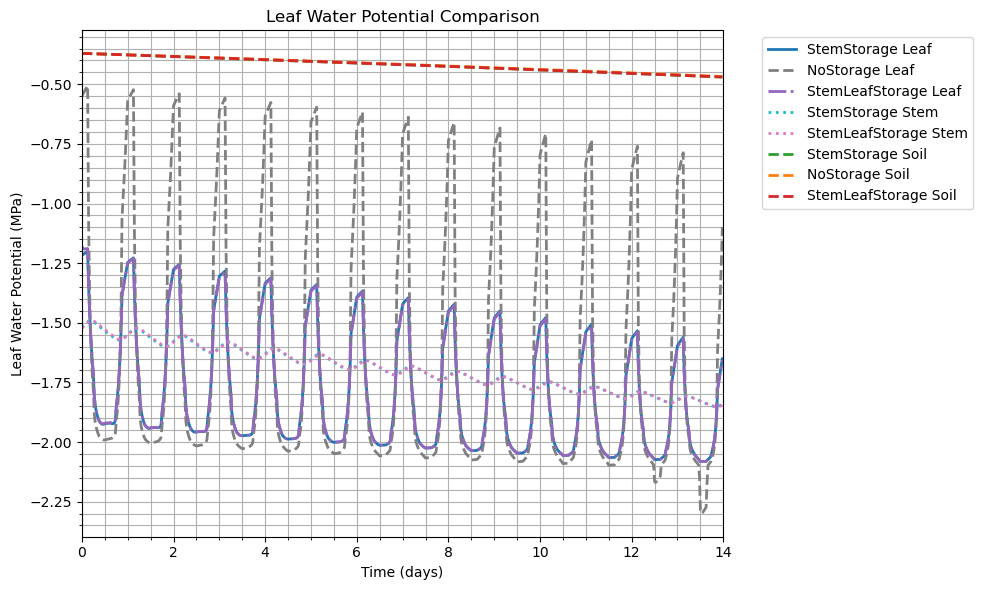

In [31]:
# Leaf water potential comparison
model_a = "StemStorage"
model_b = "NoStorage"
model_c = "StemLeafStorage"

psi_l_a = np.array(results_by_hydraulic[model_a]["psi_l"])

psi_l_b = np.array(results_by_hydraulic[model_b]["psi_l"])

psi_l_c = np.array(results_by_hydraulic[model_c]["psi_l"])



# Storage node potentials
psi_stem_a = np.array(results_by_hydraulic[model_a]["psi_w_stem"])

psi_stem_c = np.array(results_by_hydraulic[model_c]["psi_w_stem"])

# Plant conductance
gp_a = np.array(results_by_hydraulic[model_a]["gp"])
gp_b = np.array(results_by_hydraulic[model_b]["gp"])
gp_c = np.array(results_by_hydraulic[model_c]["gp"])

# Storage conductance
gw_stem_a = np.array(results_by_hydraulic[model_a]["gw_stem"])
#gw_stem_b = np.array(results_by_hydraulic[model_b]["gw_stem"])
gw_stem_c = np.array(results_by_hydraulic[model_c]["gw_stem"])

# Soil water potential
psi_soil_a = np.array(results_by_hydraulic[model_a]["psi_s"])[0,:] # Compartment 1 soil potential line
psi_soil_b = np.array(results_by_hydraulic[model_b]["psi_s"])[0,:]  # Compartment 1 soil potential line
psi_soil_c = np.array(results_by_hydraulic[model_c]["psi_s"])[0,:]  # Compartment 1 soil potential line
print(psi_soil_a)


n_plot = min(len(psi_l_a), len(psi_l_b), len(psi_l_c), len(psi_stem_a), len(psi_stem_c))
expected_steps = int(duration * 24 * 60 / timestepM)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")


time_plot = np.linspace(0.0, duration, num=n_plot, endpoint=False)



plt.figure(figsize=(10, 6))
plt.title("Leaf Water Potential Comparison")
plt.xlabel("Time (days)")
plt.ylabel("Leaf Water Potential (MPa)")
# plt.plot(time_plot, gp_a[:n_plot], linewidth=2, color="tab:cyan", label=f"{model_a} Plant Conductance")
# plt.plot(time_plot, gp_b[:n_plot], linewidth=2, color="tab:pink", label=f"{model_b} Plant Conductance")
# plt.plot(time_plot, gp_c[:n_plot], linewidth=2, color="tab:green", label=f"{model_c} Plant Conductance")
# plt.plot(time_plot, gw_stem_a[:n_plot], linewidth=2, color="tab:cyan", label=f"{model_a} Storage Conductance")
# #plt.plot(time_plot, gw_stem_b[:n_plot], linewidth=2, color="tab:pink", label=f"{model_b} Storage Conductance")
# plt.plot(time_plot, gw_stem_c[:n_plot], linewidth=2, color="tab:green", label=f"{model_c} Storage Conductance")
plt.plot(time_plot, psi_l_a[:n_plot], linewidth=2, color="tab:blue", label=f"{model_a} Leaf")
plt.plot(time_plot, psi_l_b[:n_plot], linewidth=2, linestyle="--", color="gray", label=f"{model_b} Leaf")
plt.plot(time_plot, psi_l_c[:n_plot], linewidth=2, linestyle="-.", color="tab:purple", label=f"{model_c} Leaf")
plt.plot(time_plot, psi_stem_a[:n_plot], linewidth=2, linestyle=":", color="tab:cyan", label=f"{model_a} Stem")
plt.plot(time_plot, psi_stem_c[:n_plot], linewidth=2, linestyle=":", color="tab:pink", label=f"{model_c} Stem")
plt.plot(time_plot, psi_soil_a[:n_plot], linewidth=2, linestyle="--", color="tab:green", label=f"{model_a} Soil")
plt.plot(time_plot, psi_soil_b[:n_plot], linewidth=2, linestyle="--", color="tab:orange", label=f"{model_b} Soil")
plt.plot(time_plot, psi_soil_c[:n_plot], linewidth=2, linestyle="--", color="tab:red", label=f"{model_c} Soil")
plt.xlim(0, duration)
plt.minorticks_on()
plt.grid(visible=True, which="both", axis="both")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

<>:31: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:31: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Josh.Gottlieb\AppData\Local\Temp\ipykernel_33028\875439103.py:31: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel("$\Delta \psi_l$ (MPa)")


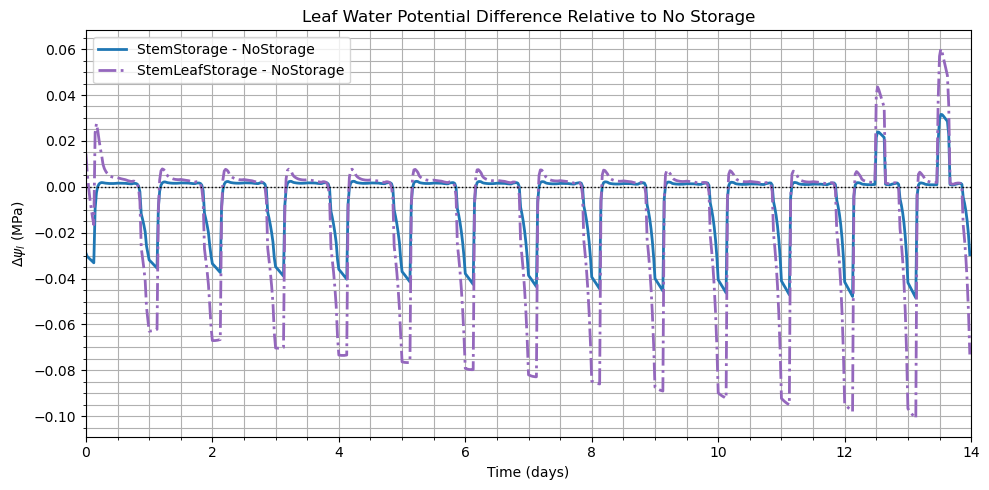

Mean StemStorage - NoStorage difference: -0.006619 MPa
Mean StemLeafStorage - NoStorage difference: -0.013293 MPa
Max absolute StemStorage - NoStorage difference: 0.048412 MPa
Max absolute StemLeafStorage - NoStorage difference: 0.100880 MPa


In [185]:
# Leaf water potential difference comparison relative to NoStorage
model_ref = "NoStorage"
model_stem = "StemStorage"
model_stem_leaf = "StemLeafStorage"

psi_ref = np.array(results_by_hydraulic[model_ref]["psi_l"])

psi_stem = np.array(results_by_hydraulic[model_stem]["psi_l"])

psi_stem_leaf = np.array(results_by_hydraulic[model_stem_leaf]["psi_l"])



n_plot = min(len(psi_ref), len(psi_stem), len(psi_stem_leaf))
expected_steps = int(duration * 24 * 60 / timestepM)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")


time_plot = np.linspace(0.0, duration, num=n_plot, endpoint=False)



psi_diff_stem = psi_stem[:n_plot] - psi_ref[:n_plot]
psi_diff_stem_leaf = psi_stem_leaf[:n_plot] - psi_ref[:n_plot]


plt.figure(figsize=(10, 5))
plt.title("Leaf Water Potential Difference Relative to No Storage")
plt.xlabel("Time (days)")
plt.ylabel("$\Delta \psi_l$ (MPa)")
plt.plot(time_plot, psi_diff_stem, linewidth=2, color="tab:blue", label=f"{model_stem} - {model_ref}")
plt.plot(time_plot, psi_diff_stem_leaf, linewidth=2, color="tab:purple", linestyle="-.", label=f"{model_stem_leaf} - {model_ref}")
plt.axhline(0.0, color="black", linestyle=":", linewidth=1)
plt.xlim(0, duration)
plt.minorticks_on()
plt.grid(visible=True, which="both", axis="both")
plt.legend()
plt.tight_layout()
plt.show()


print(f"Mean {model_stem} - {model_ref} difference: {psi_diff_stem.mean():.6f} MPa")
print(f"Mean {model_stem_leaf} - {model_ref} difference: {psi_diff_stem_leaf.mean():.6f} MPa")
print(f"Max absolute {model_stem} - {model_ref} difference: {np.abs(psi_diff_stem).max():.6f} MPa")
print(f"Max absolute {model_stem_leaf} - {model_ref} difference: {np.abs(psi_diff_stem_leaf).max():.6f} MPa")

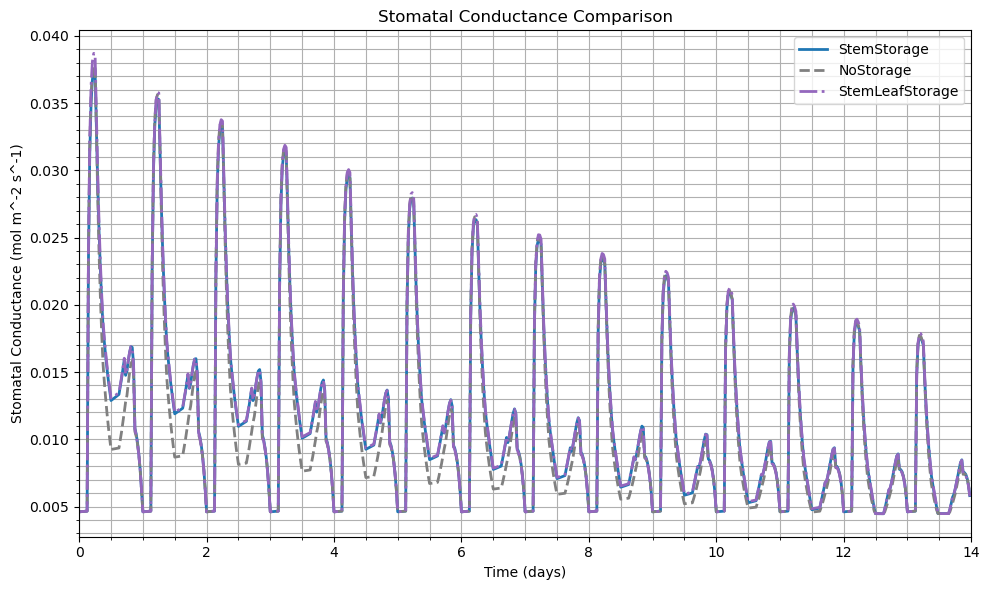

In [186]:
# Stomatal conductance comparison
model_a = "StemStorage"
model_b = "NoStorage"
model_c = "StemLeafStorage"

gs_a = np.array(results_by_hydraulic[model_a]["gsw"])

gs_b = np.array(results_by_hydraulic[model_b]["gsw"])

gs_c = np.array(results_by_hydraulic[model_c]["gsw"])



n_plot = min(len(gs_a), len(gs_b), len(gs_c))
expected_steps = int(duration * 24 * 60 / timestepM)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")


time_plot = np.linspace(0.0, duration, num=n_plot, endpoint=False)



plt.figure(figsize=(10, 6))
plt.title("Stomatal Conductance Comparison")
plt.xlabel("Time (days)")
plt.ylabel("Stomatal Conductance (mol m^-2 s^-1)")
plt.plot(time_plot, gs_a[:n_plot], linewidth=2, color="tab:blue", label=model_a)
plt.plot(time_plot, gs_b[:n_plot], linewidth=2, linestyle="--", color="gray", label=model_b)
plt.plot(time_plot, gs_c[:n_plot], linewidth=2, linestyle="-.", color="tab:purple", label=model_c)
plt.xlim(0, duration)
plt.minorticks_on()
plt.grid(visible=True, which="both", axis="both")
plt.legend()
plt.tight_layout()
plt.show()